## Change Log

- adapted from *estimate_ode_model.ipynb*

## GP

$$\text{GP} = \{\dot{R}\ |\ T_S,\ T_H,\ u\}$$

where $\dot{R}$ is the time-derivative of residual, $(T_S, T_H)$ are two-state model predictions (i.e, benchmark) of data, and $u$ is from data.

In [6]:
import os
dir = os.path.abspath('')  # directory of notebook
import sys
sys.path.append(os.path.join(dir, '..', '..'))  # package directory
from src.FoKL import FoKLRoutines
from src.FoKL.fokl_to_pyomo import fokl_to_pyomo
import pyomo.environ as pyo
import pyomo.dae as dae
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# Estimate Mechanistic Model

A second order model is for the heater/sensor combination is given by

$$
\begin{align}
C^H_p\frac{dT_{H,1}}{dt} & = U_a(T_{amb} - T_{H,1}) + U_b(T_{S,1} - T_{H,1}) + P_1u_1\\
C^S_p\frac{dT_{S,1}}{dt} & = U_b(T_{H,1} - T_{S,1}) 
\end{align}
$$

where $T_{H,1}$ is the heater temperature, $T_{S,1}$ is the sensor temperature, and $U_b$ is the heat transfer coefficient between the heater and sensor. 

<Axes: xlabel='Time', ylabel='%'>

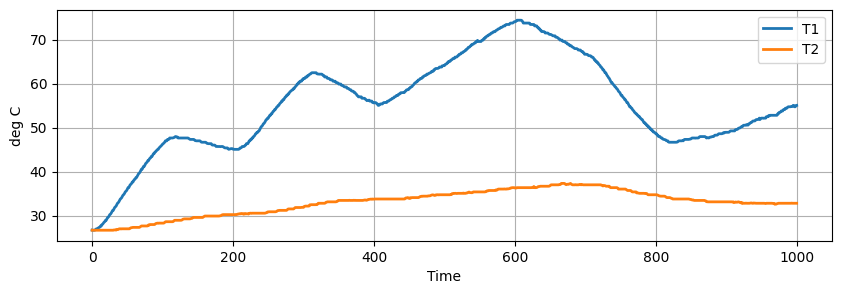

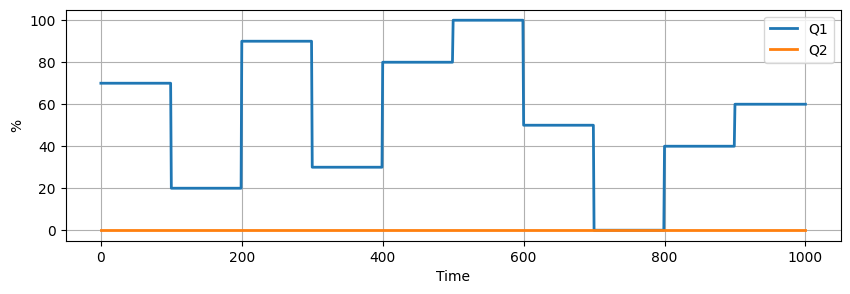

In [7]:
# Load and plot data

data_file = "step_tests.csv"

data = pd.read_csv(data_file)
data.plot(x = "Time", y=["T1", "T2"], figsize=(10, 3), grid=True, lw=2, ylabel="deg C")
data.plot(x = "Time", y=["Q1", "Q2"], figsize=(10, 3), grid=True, lw=2, ylabel="%")

,Time,TH1,TS1,Q1
0,0.00,21.000000,21.000000,50
1,1.00,21.443586,21.010943,50
2,2.00,21.878602,21.042773,50
3,3.00,22.305457,21.093899,50
4,4.00,22.724735,21.161988,50
...,...,...,...,...
995,996.00,52.220580,50.852274,50
996,997.01,52.279029,50.921111,50
997,998.00,52.335852,50.988077,50
998,999.00,52.392781,51.055210,50


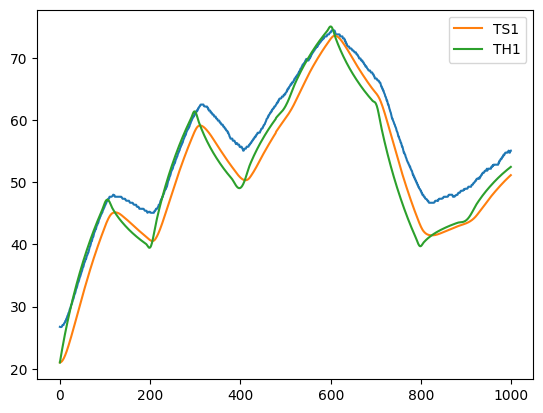

In [8]:
# Implement and test model

# known parameters
T_amb = 21 # deg C
alpha = 0.00016 # watts / (units P1 * percent U1)
P1 = 200 # P1 units
U1 = 50 # steady state value of u1 (percent)
# P2 = 100 # P2 units
# U2 = 0 # steady state value of u1 (percent)

# adjustable parameters
Ua = 0.05 # watts/deg C
Ub = 0.05 # watts/deg C
CpH = 5 # joules/deg C
CpS = 1 # joules/deg C

# extract data from experiment
t_expt = data["Time"]

def u_data(t):
    # This is slow
    return np.interp(t, t_expt, data["Q1"])

def step_tests(t):
    if t < 100:
        return 70
    elif t < 200:
        return 20
    elif t < 300:
        return 90
    elif t < 400:
        return 30
    elif t < 500:
        return 80
    elif t < 600:
        return 100
    elif t < 700: 
        return 50
    elif t < 800:
        return 0
    elif t < 900:
        return 40
    else:
        return 60

def tclab_model2(param):
    # unpack the adjustable parameters
    Ua, Ub, CpH, CpS = param
    
    # model solution
    def deriv(t, y):
        T1H, T1S = y
        dT1H = (-(Ua + Ub)*T1H + Ub*T1S + alpha*P1*step_tests(t) + Ua*T_amb)/CpH
        dT1S = Ub*(T1H - T1S)/CpS
        return [dT1H, dT1S]
    soln = solve_ivp(deriv, [min(t_expt), max(t_expt)], [T_amb, T_amb], t_eval=t_expt)
    
    # create dataframe with predictions
    pred = pd.DataFrame(columns=["Time"])
    pred["Time"] = t_expt
    pred["TH1"] = soln.y[0]
    pred["TS1"] = soln.y[1]
    pred["Q1"] = U1
    
    return pred
pred = tclab_model2([Ua, Ub, CpH, CpS])
ax = data["T1"].plot()
pred[["TS1", "TH1"]].plot(ax=ax)
pred

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.1908e+02                                    2.20e+03    
       1              2         5.8627e+02      1.33e+02       1.12e+00       2.61e+04    
       2              3         5.5009e+02      3.62e+01       1.97e-01       1.68e+04    
       3              4         5.1135e+02      3.87e+01       8.56e-02       1.06e+04    
       4              5         5.0485e+02      6.51e+00       3.91e-01       3.40e+02    
       5              7         5.0080e+02      4.05e+00       6.79e-02       4.42e+02    
       6              9         4.9662e+02      4.17e+00       3.39e-02       5.30e+02    
       7             11         4.9241e+02      4.21e+00       1.71e-02       3.26e+03    
       8             19         4.9240e+02      8.99e-03       1.57e-06       3.23e+03    
       9             21         4.9240e+02      4.48e-03       7.90e-07       3.21e+03    

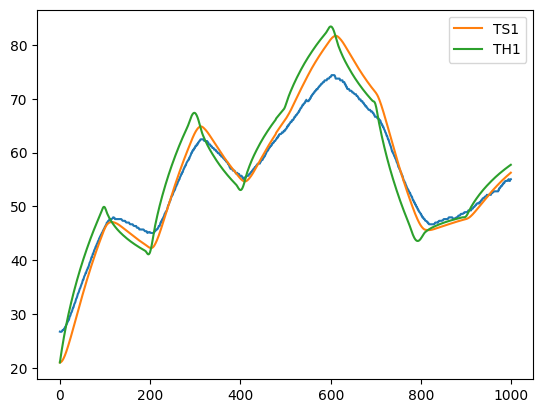

In [9]:
# Regress model

def residuals(p):
    pred = tclab_model2(p)
    return pred["TS1"] - data["T1"]

# Next step: multistart initialization

# Set initial point
p0 = [Ua, Ub, CpH, CpS]

# Set bounds (non-negative)
bnds = ([0.0, 0.0, 0.0, 0.0], [np.inf, np.inf, np.inf, np.inf])

# Perform least squares nonlinear regression
nl_results = least_squares(residuals, p0, bounds=bnds, method='trf', verbose=2, loss="arctan")
p = nl_results.x

# extract and print values
Ua, Ub, CpH, CpS = nl_results.x

# Plot fitted model
pred = tclab_model2(nl_results.x)
ax = data["T1"].plot(grid=True)
pred[["TS1", "TH1"]].plot(ax=ax)
plt.show()

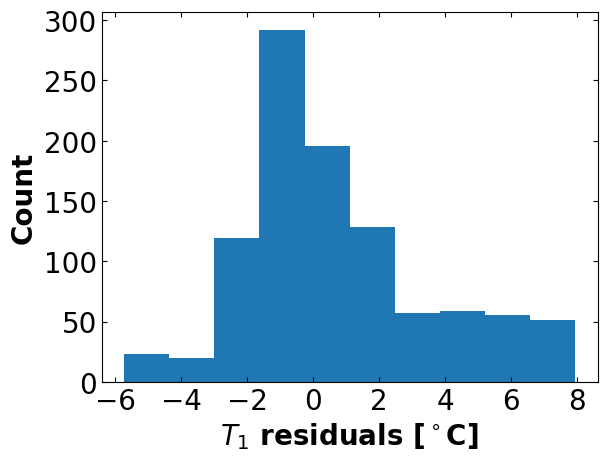

Estimated standard deviation of residuals: 2.944870244365905 deg C

Covariance of p = [Ua, Ub, CpH, CpS]
[[ 1.14120841e-07 -2.17945404e-07 -2.06193700e-05  4.66109699e-06]
 [-2.17945404e-07  6.34952132e-05 -3.70891463e-03  3.34026165e-03]
 [-2.06193700e-05 -3.70891463e-03  3.72827949e-01 -2.61854094e-01]
 [ 4.66109699e-06  3.34026165e-03 -2.61854094e-01  2.04337306e-01]]


In [10]:
# Plot histogram of residuals

### Plots residuals
r = residuals(p).to_numpy()

# define font size
fs = 20

# plot data
plt.hist(r)
plt.xlabel("$T_1$ residuals [$^\circ{}$C]",fontsize=fs,fontweight = 'bold')
plt.ylabel("Count",fontsize=fs,fontweight = 'bold')

# define tick size
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.tick_params(direction="in",top=True, right=True)

# finish plot
plt.show()

# Estimate covariance and correlation of fitted parameters

#Estimate covariance of residuals
var_residuals = r.T@r / (len(r) - len(p))
print("Estimated standard deviation of residuals:",np.sqrt(var_residuals),"deg C")

# Estimate covariance of fitted parameters
cov_p = var_residuals * np.linalg.inv(nl_results.jac.T @ nl_results.jac)

### END SOLUTION

print("\nCovariance of p = [Ua, Ub, CpH, CpS]")
print(cov_p)


## Derivative of residuals

In [11]:
def smooth(x, window):
    """Apply centered average of size window."""
    x_smooth = np.zeros_like(x)
    w2 = int(np.floor(window / 2))
    w2p1 = w2 + 1

    # bleed in:
    for i in range(w2):
        x_smooth[i] = np.mean(x[:(i + w2p1)])

    # center:
    for i in range(w2, x_smooth.size - w2):
        x_smooth[i] = np.mean(x[(i - w2):(i + w2p1)])

    # bleed out:
    for i in range(-w2, 0):
        x_smooth[i] = np.mean(x[(i - w2)::])

    return x_smooth


def gradient_h4(x, h):
    """h is step size. Order of error is h^4."""
    dx = np.zeros_like(x)

    # bleed in:
    h2 = 2 * h
    dx[0] = (x[1] - x[0]) / h
    dx[1] = (x[2] - x[0]) / h2

    # center difference:
    h12 = 12 * h
    for i in range(2, x.shape[0] - 2):
        dx[i] = (x[i - 2] - 8 * x[i - 1] + 8 * x[i + 1] - x[i + 2]) / h12
    
    # bleed out:
    dx[-2] = (x[-1] - x[-3]) / h2
    dx[-1] = (x[-1] - x[-2]) / h

    return dx

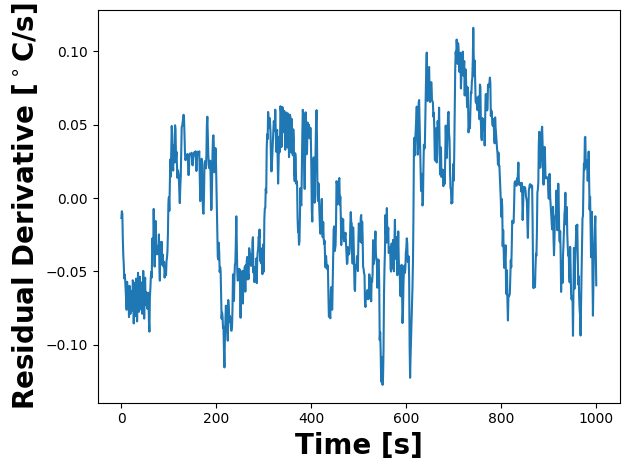

In [12]:
window = 9  # window for smoothing function

T = smooth(data["T1"], window)  # T data (smoothed)
Tp = smooth(pred["TS1"], window)  # TS prediction (smoothed)
Hp = smooth(pred["TH1"], window)  # TH prediction (smoothed)

tvec = data["Time"].values
dt = (tvec[-1] - tvec[0]) / (len(tvec) - 1)

dT = gradient_h4(T, dt)
dTp = gradient_h4(Tp, dt)

dR = dT - dTp  # derivative of residual, i.e., R == T - Tp --> dT = dT - dTp

# plot data
plt.plot(tvec, dR)
plt.xlabel("Time [s]", fontsize=fs,fontweight = 'bold')
plt.ylabel("Residual Derivative [$^\circ{}$C/s]", fontsize=fs, fontweight = 'bold')
plt.tight_layout()

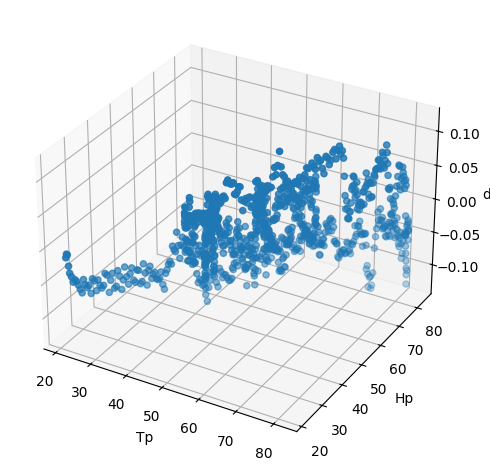

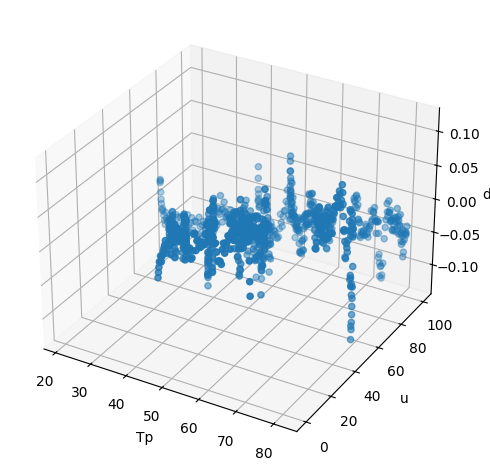

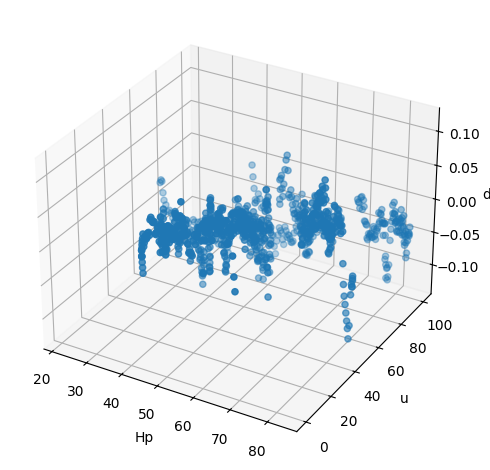

In [13]:
u = data["Q1"].values

for i in range(3):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    
    if i == 0:
        ax.scatter(Tp, Hp, dR)
        ax.set_xlabel("Tp")
        ax.set_ylabel("Hp")

    elif i == 1:
        ax.scatter(Tp, u, dR)
        ax.set_xlabel("Tp")
        ax.set_ylabel("u")

    elif i == 2:
        ax.scatter(Hp, u, dR)
        ax.set_xlabel("Hp")
        ax.set_ylabel("u")

    ax.set_zlabel("dR")
    fig.tight_layout()

Text(0.5, 0, 'u')

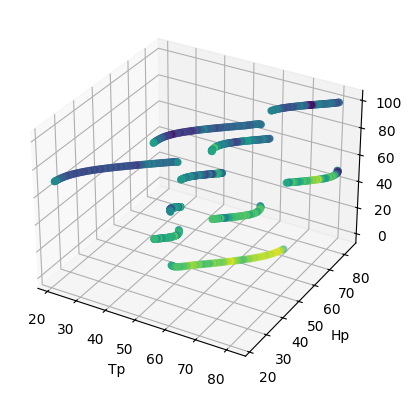

In [14]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(Tp, Hp, u, c=dR)
ax.set_xlabel("Tp")
ax.set_ylabel("Hp")
ax.set_zlabel("u")

In [15]:
filename = os.path.join(dir, "models", "v13.fokl")
try:
    GP = FoKLRoutines.load(filename)
except Exception as exception:
    GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True, way3=True)
    GP.fit([Tp, Hp, u], dR, clean=True, pillow=[[0.01, 0.05], [0.01, 0.05], [0, 0]])
    GP.save(filename)

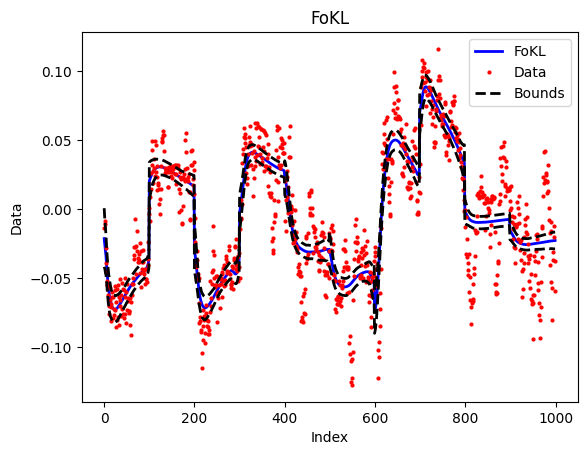

In [16]:
_ = GP.coverage3(plot=True)

## Pyomo

In [94]:
Tamb = 24

def r(t):
    return np.interp(t, [0, 50, 150, 450, 550, 999], np.array([Tamb, Tamb, 60, 60, 35, 35]))

benchmark = np.loadtxt(os.path.join(dir, 'data', 'u1_benchmark_solution.csv'), delimiter=',')
benchmark = np.concatenate([np.array([0, 0])[np.newaxis, :],
                            benchmark[1:107, :],
                            benchmark[130:218, :],
                            benchmark[243:354, :],
                            benchmark[370:-1, :]], axis=0)  # remove oscillations

def u_bmrk(t):
    return np.interp(t, benchmark[:, 0], benchmark[:, 1])

In [108]:
m = pyo.ConcreteModel("TCLab Heater with GP Model")
m.t = dae.ContinuousSet(bounds=(0, 999))

m.T = pyo.Var(m.t)  # , bounds = GP.minmax[0])  # TS1
m.H = pyo.Var(m.t)  # , bounds = GP.minmax[1])  # TH1
m.u = pyo.Var(m.t, initialize=50)  # , bounds = GP.minmax[2])

# m.dR = pyo.Var(m.t)  # derivative of residual

nfe = 100
pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=nfe)

m.T[0].fix(Tamb)
m.H[0].fix(Tamb)
# for t in m.t:  # COMMENT-OUT ONE
#     # m.u[t].fix(u_bmrk(t))  # fixed (i.e., benchmark)
#     m.u[t] = u_bmrk(t)  # free (i.e., optimal)  
    
# fokl_to_pyomo(GP, [m.T, m.H, m.u], m.dR, m, m.t)

In [109]:
m.dH = dae.DerivativeVar(m.H, wrt=m.t)
m.dT = dae.DerivativeVar(m.T, wrt=m.t)

# Differential equation for TH1
@m.Constraint(m.t)
def dHdt(m, t):
    return m.dH[t] == (-(Ua + Ub)*m.H[t] + Ub*m.T[t] + alpha*P1*m.u[t] + Ua*T_amb)/CpH

# Differential equation for TS1
@m.Constraint(m.t)
def dTdt(m, t):
    return m.dT[t] == Ub*(m.H[t] - m.T[t])/CpS  # + m.GP0_y[t]  # + m.dR[t], but as Expression no Var

In [110]:
@m.Integral(m.t)
def ise(m, t):
    return (r(t) - m.T[t]) ** 2

@m.Objective(sense=pyo.minimize)
def obj(m):
    return m.ise

In [111]:
solver = pyo.SolverFactory('ipopt')
solver.options['linear_solver'] = 'ma57'
solver.solve(m , tee=True)

results_T = m.T[:]()
results_H = m.H[:]()
results_u = m.u[:]()

Ipopt 3.13.2: linear_solver=ma57


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        compu

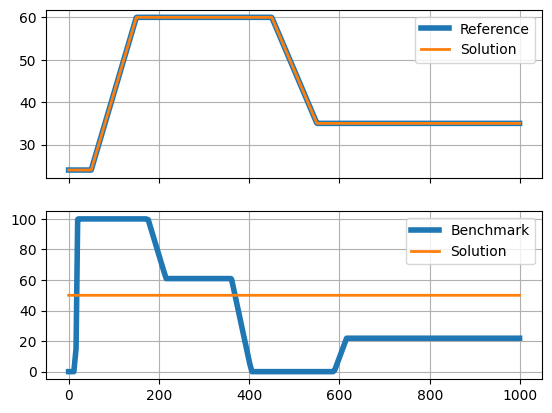

In [113]:
fig, axs = plt.subplots(2, sharex=True)

axs[0].plot(m.t, r(m.t), linewidth=4, label="Reference")
axs[0].plot(m.t, results_T, linewidth=2, label="Solution")

axs[1].plot(m.t, u_bmrk(m.t), linewidth=4, label="Benchmark")
axs[1].plot(m.t, results_u, linewidth=2, label="Solution")

for ax in axs:
    ax.legend()
    ax.grid()

## Validation on sine test without Pyomo

In [116]:
test = pd.read_csv(os.path.join(dir, "data", "tclab_sine_test.csv"))

tvec_test = test["Time"].values
T_test = test["T1"].values
u_test = test["Q1"].values

n = len(tvec_test)
dt_test = (tvec_test[-1] - tvec_test[0]) / (n - 1)

In [133]:
pred_T = np.zeros(n)
pred_T_GP = np.zeros(n)
pred_H = np.zeros(n)
pred_H_GP = np.zeros(n)

pred_T[0] = Tamb
pred_T_GP[0] = Tamb
pred_H[0] = Tamb
pred_H_GP[0] = Tamb

GP_eval = []
for i in range(n - 1):
    dT_i = Ub*(pred_H[i] - pred_T[i])/CpS
    
    GP_eval.append(GP.evaluate([pred_T_GP[i], pred_H_GP[i], u_test[i]], clean=True, SingleInstance=True)[0])
    dT_i_GP = dT_i + GP_eval[i]
    
    dH_i = (-(Ua + Ub)*pred_H[i] + Ub*pred_T[i] + alpha*P1*u_test[i] + Ua*T_amb)/CpH
    dH_i_GP = (-(Ua + Ub)*pred_H_GP[i] + Ub*pred_T_GP[i] + alpha*P1*u_test[i] + Ua*T_amb)/CpH

    pred_T[i + 1] = pred_T[i] + dt_test * dT_i
    pred_T_GP[i + 1] = pred_T_GP[i] + dt_test * dT_i_GP
    pred_H[i + 1] = pred_H[i] + dt_test * dH_i
    pred_H_GP[i + 1] = pred_H_GP[i] + dt_test * dH_i_GP

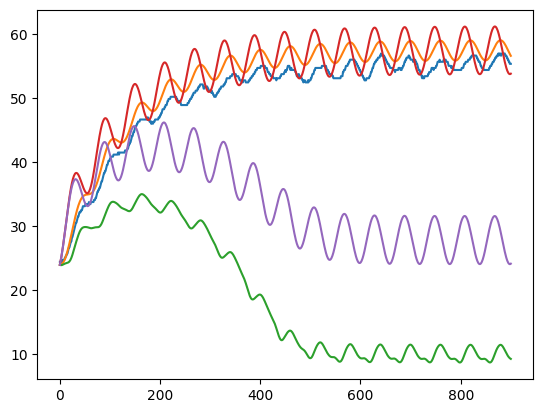

In [134]:
fig, ax = plt.subplots(1, sharex=True)

ax.plot(tvec_test, T_test)
ax.plot(tvec_test, pred_T)
ax.plot(tvec_test, pred_T_GP)
ax.plot(tvec_test, pred_H)
ax.plot(tvec_test, pred_H_GP)

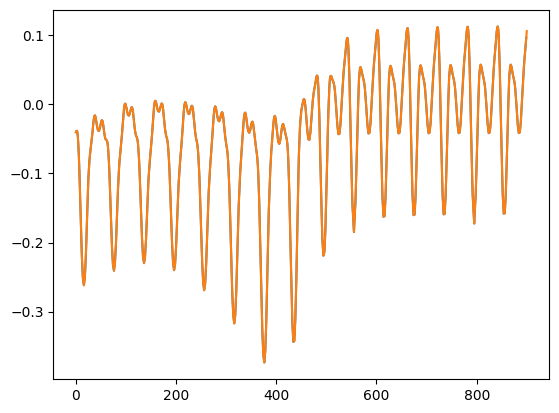

In [135]:
plt.plot(GP_eval)
plt.plot(GP.evaluate([pred_T_GP, pred_H_GP, u_test], clean=True))

In [136]:
GP.minmax

[[20.471889786341208, 84.68169271427509],
 [21.52745039652244, 86.38561838772664],
 [0.0, 100.0]]

In [137]:
pred_H_GP.min()
pred_H_GP.max()

46.2258342227021

# BENCHMARK

Reference: https://dowlinglab.github.io/pyomo-doe/notebooks/pyomo_simulation.html#controlling-to-a-reference-tractory

In [17]:
results_benchmark = pd.DataFrame()
results_GP = pd.DataFrame()

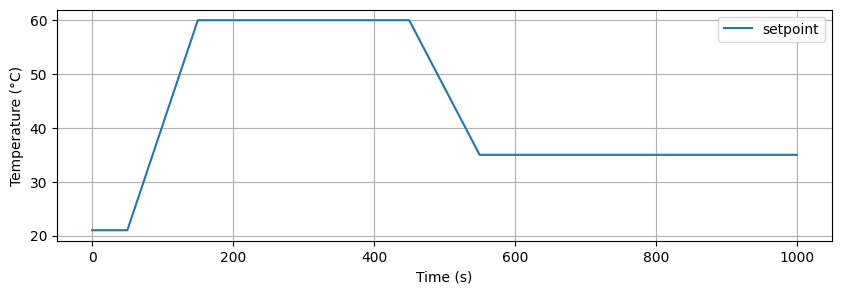

In [18]:
# time grid
tf = 1000
dt = 2
n = round(tf / dt)
t_grid = np.linspace(0, 1000, n + 1)

# ambient temperature
Tamb = 21


# setpoint/reference
def r(t):
    return np.interp(t, [0, 50, 150, 450, 550], [Tamb, Tamb, 60, 60, 35])


# plot the setpoint function
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(t_grid, r(t_grid), label="setpoint")
ax.set_ylabel('Temperature (°C)')
ax.set_xlabel("Time (s)")
ax.legend()
ax.grid(True)

In [19]:
# Create a Pyomo model
m = pyo.ConcreteModel('TCLab Heater/Sensor')

# Define time domain
m.t = dae.ContinuousSet(bounds=(0, tf))

# Define the state variables as a function of time
m.Th1 = pyo.Var(m.t)
m.Ts1 = pyo.Var(m.t)

# Define the derivatives of the state variables
m.dTh1 = dae.DerivativeVar(m.Th1)
m.dTs1 = dae.DerivativeVar(m.Ts1)

# Define the control variable (heater power) as a function of time
m.u1 = pyo.Var(m.t, bounds=(0, 100))


# Define the integral of the squared error
@m.Integral(m.t)
def ise(m, t):
    return (r(t) - m.Th1[t]) ** 2


# Define the first differential equation
@m.Constraint(m.t)
def heater1(m, t):
    return (
        CpH * m.dTh1[t]
        == Ua * (Tamb - m.Th1[t]) + Ub * (m.Ts1[t] - m.Th1[t]) + alpha * P1 * m.u1[t]
    )


# Define the second differential equation
@m.Constraint(m.t)
def sensor1(m, t):
    return CpS * m.dTs1[t] == Ub * (m.Th1[t] - m.Ts1[t])


# Fix the initial conditions
m.Th1[0].fix(Tamb)
m.Ts1[0].fix(Tamb)


# Define the objective function
@m.Objective(sense=pyo.minimize)
def objective(m):
    return m.ise


# Apply a collocation method to numerically integrate the differential equations
pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=200, wrt=m.t)

In [20]:
# Call our nonlinear optimization/equation solver, Ipopt
pyo.SolverFactory('ipopt').solve(m, tee=True)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 2402, 'Number of variables': 3003, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'Ipopt 3.13.2\\x3a Optimal Solution Found', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.33297133445739746}], 'Solution': [OrderedDict([('number of solutions', 0), ('number of solutions displayed', 0)])]}

In [21]:
results_benchmark["TS1"] = m.Ts1[:]()
results_benchmark["TH1"] = m.Th1[:]()
results_benchmark["u1"] = m.u1[:]()
results_benchmark["Time"] = m.t.data()

# BENCHMARK WITH dResidual

In [22]:
# Create a Pyomo model
m = pyo.ConcreteModel('TCLab Heater/Sensor')

# Define time domain
m.t = dae.ContinuousSet(bounds=(0, tf))

# Define the state variables as a function of time
m.Th1 = pyo.Var(m.t)
m.Ts1 = pyo.Var(m.t)

# Define the derivatives of the state variables
m.dTh1 = dae.DerivativeVar(m.Th1)
m.dTs1 = dae.DerivativeVar(m.Ts1)

# Define the control variable (heater power) as a function of time
m.u1 = pyo.Var(m.t, bounds=(0, 100))


# Define the integral of the squared error
@m.Integral(m.t)
def ise(m, t):
    return (r(t) - m.Th1[t]) ** 2


# Define the first differential equation
@m.Constraint(m.t)
def heater1(m, t):
    return (
        CpH * m.dTh1[t]
        == Ua * (Tamb - m.Th1[t]) + Ub * (m.Ts1[t] - m.Th1[t]) + alpha * P1 * m.u1[t]
    )


# # Define the second differential equation
# @m.Constraint(m.t)
# def sensor1(m, t):
#     return CpS * m.dTs1[t] == Ub * (m.Th1[t] - m.Ts1[t])


# Fix the initial conditions
m.Th1[0].fix(Tamb)
m.Ts1[0].fix(Tamb)


# Define the objective function
@m.Objective(sense=pyo.minimize)
def objective(m):
    return m.ise


# Apply a collocation method to numerically integrate the differential equations
pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=200, wrt=m.t)

In [23]:
m.dR = pyo.Var(m.t)
fokl_to_pyomo(GP, [m.Ts1, m.Th1, m.u1], m.dR, m, m.t)

# Define the second differential equation
@m.Constraint(m.t)
def sensor1(m, t):
    return m.dTs1[t] == (Ub * (m.Th1[t] - m.Ts1[t])) /CpS + m.dR[t]  # + m.GP0_y[t]

In [24]:
# Call our nonlinear optimization/equation solver, Ipopt
pyo.SolverFactory('ipopt').solve(m, tee=True)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 3003, 'Number of variables': 3604, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'Ipopt 3.13.2\\x3a Optimal Solution Found', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 3.2519915103912354}], 'Solution': [OrderedDict([('number of solutions', 0), ('number of solutions displayed', 0)])]}

In [25]:
results_GP["TS1"] = m.Ts1[:]()
results_GP["TH1"] = m.Th1[:]()
results_GP["u1"] = m.u1[:]()
results_GP["Time"] = m.t.data()
results_GP["dR"] = m.dR[:]()

# COMPARE

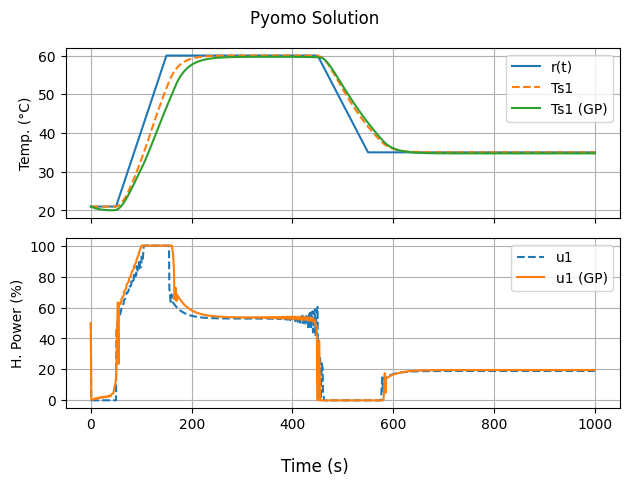

In [26]:
fig, ax = plt.subplots(2, 1, sharex=True)
fig.suptitle("Pyomo Solution")
fig.supxlabel("Time (s)")
ax[0].set_ylabel("Temp. (°C)")
ax[1].set_ylabel("H. Power (%)")

ax[0].plot(tvec, r(tvec), label="r(t)")

ax[0].plot(results_benchmark["Time"], results_benchmark["TS1"], '--', label="Ts1")
ax[0].plot(results_GP["Time"], results_GP["TS1"], label="Ts1 (GP)")

# ax[0].plot(results_benchmark["Time"], results_benchmark["TH1"], '--', label="Th1")
# ax[0].plot(results_GP["Time"], results_GP["TH1"], label="Th1 (GP)")

ax[1].plot(results_benchmark["Time"], results_benchmark["u1"], '--', label="u1")
ax[1].plot(results_GP["Time"], results_GP["u1"], label="u1 (GP)")

for i in range(2):
    ax[i].legend()
    ax[i].grid()
    
fig.tight_layout()

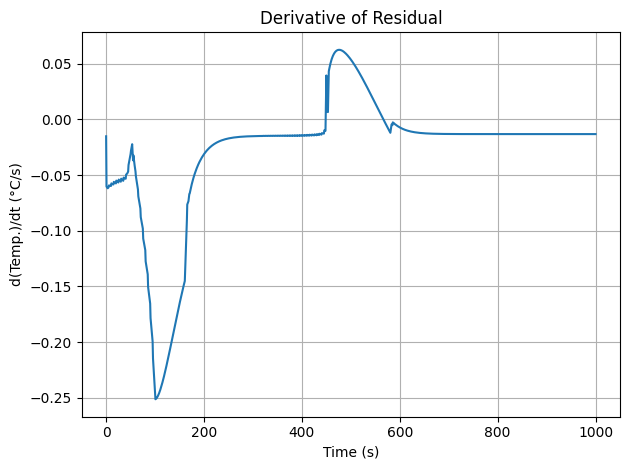

In [28]:
plt.title("Derivative of Residual")
plt.xlabel("Time (s)")
plt.ylabel("d(Temp.)/dt (°C/s)")
plt.plot(results_GP["Time"], results_GP["dR"])
plt.grid()
plt.tight_layout()